In [ ]:
!pip install pennylane

In [ ]:
## 1. Load Libraries
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd

In [ ]:
angles = pd.read_csv("tnbc_quantum.csv").values.astype(float)
angles[:5]

array([[0.05346054, 1.43533954, 0.        ],
       [0.05346054, 1.43533954, 0.        ],
       [0.05346054, 1.43533954, 0.        ],
       [0.1257895 , 1.36886716, 0.12693304],
       [0.1257895 , 1.36886716, 0.12693304]])

In [ ]:
n_qubits = angles.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

In [ ]:
## 4. Define VQC Block

def vqc_block(params, sample_idx, depth):

    # Angle embedding
    for i in range(n_qubits):
        qml.RY(angles[sample_idx, i], wires=i)

    # Variational layers
    for d in range(depth):

        # CNOT entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

        # Trainable RZ rotations
        for i in range(n_qubits):
            qml.RZ(params[d, i], wires=i)

In [ ]:
## 5. Full Circuit

@qml.qnode(dev)
def circuit(params, sample_idx, depth):

    vqc_block(params, sample_idx, depth)

    return qml.expval(qml.PauliX(0))

In [ ]:
## 6. Test Circuit

# Create parameters for up to 3 layers
params = pnp.random.uniform(
    0,
    np.pi,
    size=(3, n_qubits)
)

sample_idx = 0

# Test depth 1
output_depth_1 = circuit(params, sample_idx, depth=1)

# Test depth 2
output_depth_2 = circuit(params, sample_idx, depth=2)

# Test depth 3
output_depth_3 = circuit(params, sample_idx, depth=3)

print("Depth 1 output:", output_depth_1)
print("Depth 2 output:", output_depth_2)
print("Depth 3 output:", output_depth_3)

Depth 1 output: 0.03149880687095252
Depth 2 output: 0.0
Depth 3 output: 0.0


In [ ]:
print(angles.shape)
print(angles.dtype)
print(type(angles[0, 0]))
print(angles[0, 0])

(31006, 3)
float64
<class 'numpy.float64'>
0.0534605356466731


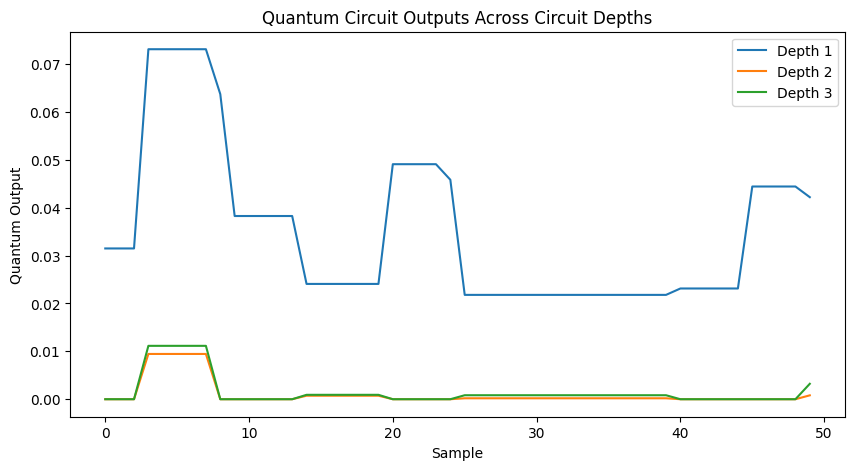

In [ ]:
## 7. Visualize Circuit Output Across Samples

import matplotlib.pyplot as plt

depth_1_outputs = []
depth_2_outputs = []
depth_3_outputs = []

num_samples = min(50, len(angles))

for i in range(num_samples):

    depth_1_outputs.append(
        circuit(params, i, depth=1)
    )

    depth_2_outputs.append(
        circuit(params, i, depth=2)
    )

    depth_3_outputs.append(
        circuit(params, i, depth=3)
    )

plt.figure(figsize=(10, 5))

plt.plot(depth_1_outputs, label="Depth 1")
plt.plot(depth_2_outputs, label="Depth 2")
plt.plot(depth_3_outputs, label="Depth 3")

plt.xlabel("Sample")
plt.ylabel("Quantum Output")
plt.title("Quantum Circuit Outputs Across Circuit Depths")
plt.legend()
plt.show()

In [ ]:
## 8. Experiment with Circuit Depth

print("Average Depth 1 output:", np.mean(depth_1_outputs))
print("Average Depth 2 output:", np.mean(depth_2_outputs))
print("Average Depth 3 output:", np.mean(depth_3_outputs))

Average Depth 1 output: 0.035292552177554934
Average Depth 2 output: 0.0011088760741803038
Average Depth 3 output: 0.0015402778031799237


In [ ]:
print("Depth 1 standard deviation:", np.std(depth_1_outputs))
print("Depth 2 standard deviation:", np.std(depth_2_outputs))
print("Depth 3 standard deviation:", np.std(depth_3_outputs))

Depth 1 standard deviation: 0.016451648001727374
Depth 2 standard deviation: 0.002793470948545046
Depth 3 standard deviation: 0.0032533464968809798


In [ ]:
## 9. Save Circuit Outputs

pd.DataFrame({
    "depth_1": depth_1_outputs,
    "depth_2": depth_2_outputs,
    "depth_3": depth_3_outputs
}).to_csv("vqc_outputs.csv", index=False)

In [ ]:
from google.colab import files

files.download("vqc_outputs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("cbio_seer_merged_tnbc.csv")

In [ ]:
assert angles.shape[0] == df.shape[0],

In [ ]:
label_map = {'Alive': 0, 'Living': 0, 'Dead': 1, 'Died of Disease': 1, 'Died of Other Causes': 1}
df['tnbc_label'] = df['vital_status'].map(label_map)
y = df['tnbc_label'].values

X_classical = df[['tumor_size', 'age', 'nodes_positive']].astype(float).values

In [ ]:
from sklearn.model_selection import train_test_split

all_idx = np.arange(len(angles))
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42, stratify=y)

y_train, y_test = y[train_idx], y[test_idx]

In [ ]:
depth = 2  # or whichever depth you want to report as your main result

params = pnp.random.uniform(0, np.pi, size=(depth, n_qubits))

X_train_q = np.array([circuit(params, idx, depth) for idx in train_idx])
X_test_q  = np.array([circuit(params, idx, depth) for idx in test_idx])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_classical, X_test_classical = X_classical[train_idx], X_classical[test_idx]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_classical, y_train)
y_pred_rf = rf.predict(X_test_classical)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Classical RF accuracy:", rf_accuracy)

Classical RF accuracy: 0.7168655272492744


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_q.reshape(-1, 1), y_train)
y_pred_hybrid = clf.predict(X_test_q.reshape(-1, 1))
hybrid_accuracy = accuracy_score(y_test, y_pred_hybrid)
print("Hybrid model accuracy:", hybrid_accuracy)

Hybrid model accuracy: 0.6131892937762012


In [ ]:
print(f"\nClassical RF accuracy: {rf_accuracy:.4f}")
print(f"Hybrid (VQC + LogReg) accuracy: {hybrid_accuracy:.4f}")

pd.DataFrame({
    "quantum_output": X_test_q,
    "true_label": y_test,
    "pred_label_hybrid": y_pred_hybrid,
}).to_csv("hybrid_results.csv", index=False)


Classical RF accuracy: 0.7169
Hybrid (VQC + LogReg) accuracy: 0.6132
